In [2]:
#Predicting Coupon Acceptance:
#Goal: Use machine learning to predict if users will accept coupons:

In [3]:
#Import necessary libraries:

In [1]:
import os
import numpy as np   # Import NumPy for numerical operations
import pandas as pd  # Import Pandas for data manipulation and analysis
import matplotlib.pyplot as plt  # Import Matplotlib for data visualization
import seaborn as sns  # Import Seaborn for enhanced data visualization

# Import machine learning utilities
from sklearn.model_selection import train_test_split  # Split data into training and testing sets
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler  # Encode categorical variables and standardize features
from sklearn.linear_model import LogisticRegression, RidgeClassifier, Perceptron  # Import Logistic Regression model
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.svm import SVC, LinearSVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB, BernoulliNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Import XGBoost library for gradient boosting
import xgboost as xgb  # Import the XGBoost library
from xgboost import XGBClassifier  # Import XGBoost classifier for supervised learning tasks

# Import metrics for model evaluation
from sklearn.metrics import accuracy_score, classification_report  # Evaluate model performance
# Set the Seaborn style for better visualization
sns.set()  # Enhances the aesthetics of plots

# Suppress warnings to avoid cluttering the output
import warnings  
warnings.filterwarnings('ignore')  # Ignores all warning messages

In [2]:
# Load dataset from a CSV file into a Pandas DataFrame
df = pd.read_csv("Ds_Data.csv")  

# Display the first few rows of the dataset to get an overview of the data structure
df.head()

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
0,No Urgent Place,Alone,Sunny,55,Restaurant(<20),1d,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,Carry out & Take away,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,Coffee House,2h,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,Coffee House,1d,Female,21,Unmarried partner,1,...,never,NaN,4~8,1~3,1,1,0,0,1,0


In [72]:
df.shape

(12684, 25)

In [73]:
# Checking duplicate values
df.duplicated().sum()

np.int64(291)

In [74]:
# Dropping the Duplicates from the dataset
df = df.drop_duplicates(ignore_index=True)

In [75]:
# Checking Duplicates Value after Dropping them
df.duplicated().sum()

np.int64(0)

In [76]:
#Check for missing values and Handleing missing values in the Dataset:

In [77]:
#Finding the nullvalues in the dataset
df.isnull().sum()

destination                 0
passanger                   0
weather                     0
temperature                 0
coupon                      0
expiration                  0
gender                      0
age                         0
maritalStatus               0
has_children                0
education                   0
occupation                  0
income                      0
car                     12287
Bar                       106
CoffeeHouse               215
CarryAway                 148
RestaurantLessThan20      128
Restaurant20To50          188
toCoupon_GEQ5min            0
toCoupon_GEQ15min           0
toCoupon_GEQ25min           0
direction_same              0
direction_opp               0
Accept(Y/N?)                0
dtype: int64

In [78]:
df.isnull().sum().sum()

np.int64(13072)

In [79]:
missing_values = df.isnull().sum() / len(df) * 100  # Calculate the percentage of missing values for each column  

# Filter only columns with missing values and sort them in descending order  
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)  

# Display the missing values percentage  
missing_values  

car                     99.144678
CoffeeHouse              1.734850
Restaurant20To50         1.516985
CarryAway                1.194223
RestaurantLessThan20     1.032841
Bar                      0.855322
dtype: float64

In [80]:
# From the above we observe that 99% of the car column contains null values so we will drop it
df.drop(columns=["car"], inplace=True)

# Check for remaining missing values in the dataset
df.isnull().sum()

destination               0
passanger                 0
weather                   0
temperature               0
coupon                    0
expiration                0
gender                    0
age                       0
maritalStatus             0
has_children              0
education                 0
occupation                0
income                    0
Bar                     106
CoffeeHouse             215
CarryAway               148
RestaurantLessThan20    128
Restaurant20To50        188
toCoupon_GEQ5min          0
toCoupon_GEQ15min         0
toCoupon_GEQ25min         0
direction_same            0
direction_opp             0
Accept(Y/N?)              0
dtype: int64

In [81]:
#Filling missing values using Imputer method:

In [82]:
# Fill missing categorical values with mode (most frequent value)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)

# Fill missing numerical values with median (to prevent outlier influence)
numerical_cols = df.select_dtypes(include=['number']).columns
for col in numerical_cols:
    df[col].fillna(df[col].median(),inplace=True)

In [83]:
# Verify missing values are handled
df.isnull().sum()

destination             0
passanger               0
weather                 0
temperature             0
coupon                  0
expiration              0
gender                  0
age                     0
maritalStatus           0
has_children            0
education               0
occupation              0
income                  0
Bar                     0
CoffeeHouse             0
CarryAway               0
RestaurantLessThan20    0
Restaurant20To50        0
toCoupon_GEQ5min        0
toCoupon_GEQ15min       0
toCoupon_GEQ25min       0
direction_same          0
direction_opp           0
Accept(Y/N?)            0
dtype: int64

In [85]:
#Checking the number of rows and columns after dropping the 'car' column in our dataset
df.shape

(12393, 24)

In [18]:
# Generate descriptive statistics for numerical columns in the dataset
df.describe()

,temperature,has_children,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
count,12393.000000,12393.000000,12393.0,12393.000000,12393.000000,12393.000000,12393.000000,12393.000000
mean,63.252643,0.415557,1.0,0.563625,0.118051,0.213750,0.786250,0.565803
std,19.075396,0.492838,0.0,0.495955,0.322681,0.409969,0.409969,0.495671
min,30.000000,0.000000,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,55.000000,0.000000,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,80.000000,0.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,80.000000,1.000000,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
max,80.000000,1.000000,1.0,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
# Check dataset info including column names, data types, and non-null values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12393 entries, 0 to 12392
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12393 non-null  object
 1   passanger             12393 non-null  object
 2   weather               12393 non-null  object
 3   temperature           12393 non-null  int64 
 4   coupon                12393 non-null  object
 5   expiration            12393 non-null  object
 6   gender                12393 non-null  object
 7   age                   12393 non-null  object
 8   maritalStatus         12393 non-null  object
 9   has_children          12393 non-null  int64 
 10  education             12393 non-null  object
 11  occupation            12393 non-null  object
 12  income                12393 non-null  object
 13  Bar                   12393 non-null  object
 14  CoffeeHouse           12393 non-null  object
 15  CarryAway             12393 non-null

In [7]:
df.columns

Index(['destination', 'passanger', 'weather', 'temperature', 'coupon',
       'expiration', 'gender', 'age', 'maritalStatus', 'has_children',
       'education', 'occupation', 'income', 'car', 'Bar', 'CoffeeHouse',
       'CarryAway', 'RestaurantLessThan20', 'Restaurant20To50',
       'toCoupon_GEQ5min', 'toCoupon_GEQ15min', 'toCoupon_GEQ25min',
       'direction_same', 'direction_opp', 'Accept(Y/N?)'],
      dtype='object')

In [20]:
#Function to detect and handle outliers using IQR:

Outliers Count per Column: {'temperature': 0, 'has_children': 0, 'toCoupon_GEQ5min': 0, 'toCoupon_GEQ15min': 0, 'toCoupon_GEQ25min': 1463, 'direction_same': 2649, 'direction_opp': 2649, 'Accept(Y/N?)': 0}


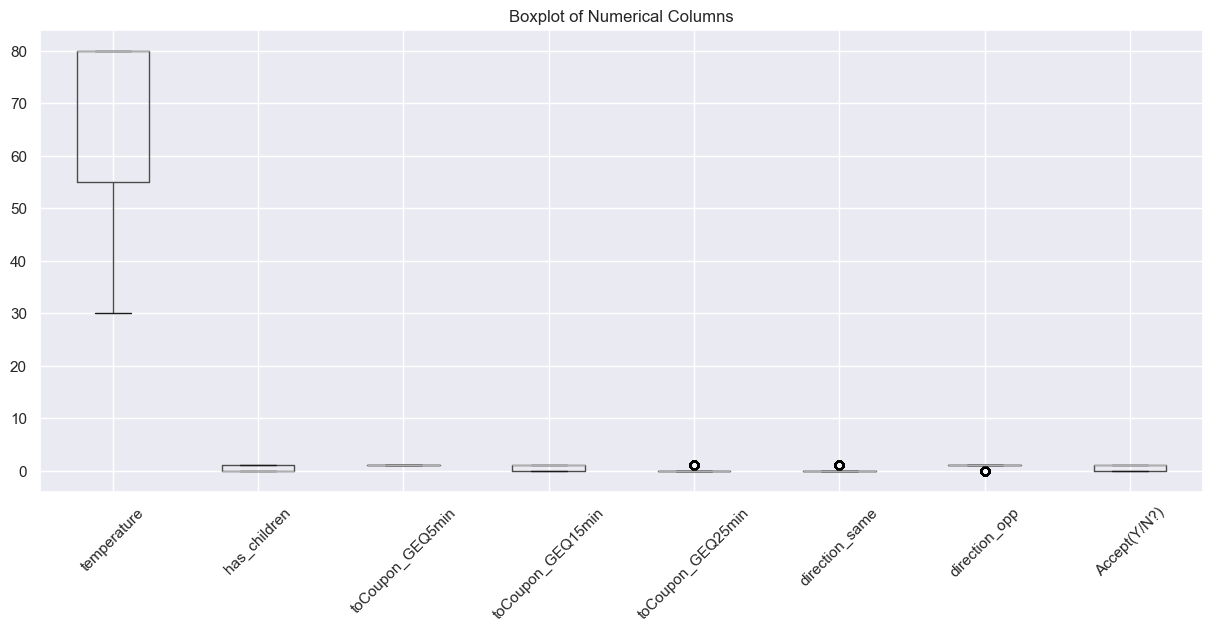

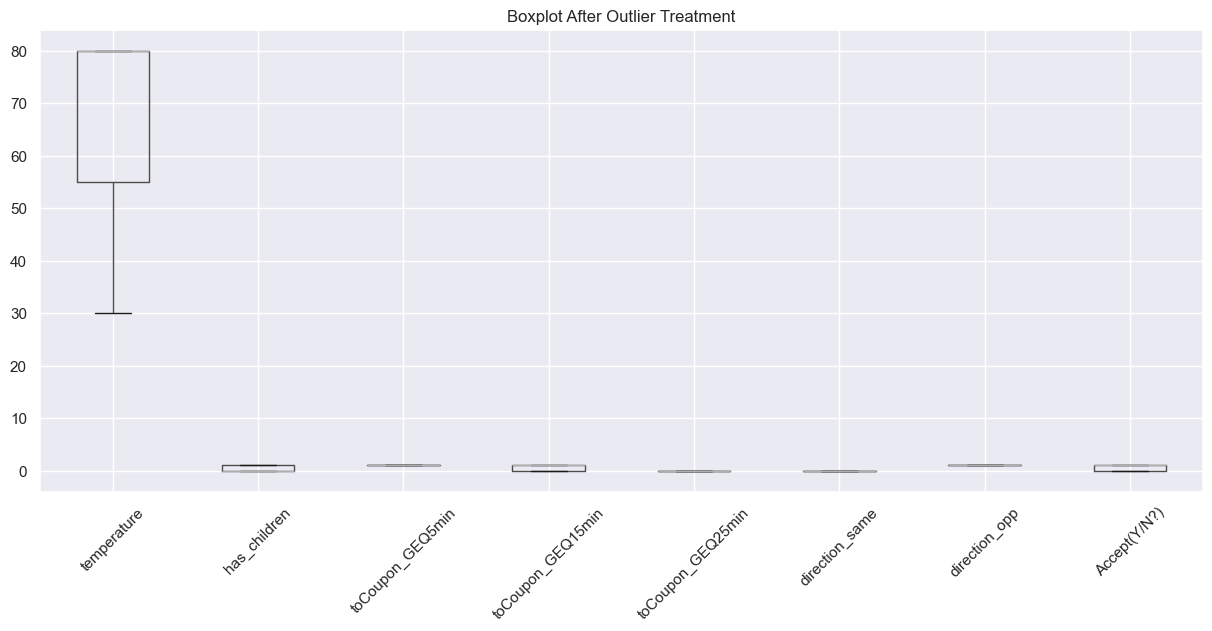

Outliers Count per Column: {'temperature': 0, 'has_children': 0, 'toCoupon_GEQ5min': 0, 'toCoupon_GEQ15min': 0, 'toCoupon_GEQ25min': 1463, 'direction_same': 2649, 'direction_opp': 2649, 'Accept(Y/N?)': 0}


In [21]:
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25) # First quartile (25th percentile)
    Q3 = data[column].quantile(0.75)  # Third quartile (75th percentile)
    IQR = Q3 - Q1 # Interquartile Range (IQR)

     # Define lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
     # Return rows where values are outside the bounds
    return data[(data[column] < lower_bound) | (data[column] > upper_bound)]

# Detect outliers in numerical columns
numerical_columns = df.select_dtypes(include=['number']).columns
outliers_dict = {} # Dictionary to store outlier counts per column

# Loop through numerical columns and count outliers
for col in numerical_columns:
    outliers = detect_outliers_iqr(df, col)
    outliers_dict[col] = len(outliers)  # Store count of outliers per column

# Display outliers count per columnbb
print("Outliers Count per Column:", outliers_dict)

# Boxplot for visualization
plt.figure(figsize=(15, 6)) # Set figure size
df[numerical_columns].boxplot()  # Generate boxplot for numerical columns
plt.xticks(rotation=45) # Rotate x-axis labels for better readability
plt.title("Boxplot of Numerical Columns") # Set plot title
plt.show() # Display the plot
# Function to handle outliers by capping
def treat_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25) # First quartile
    Q3 = data[column].quantile(0.75) # Third quartile
    IQR = Q3 - Q1 # Interquartile Range (IQR)
    
    # Define lower and upper bounds for outliers
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Cap values outside the bounds to the respective thresholds
    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])

# Apply treatment to numerical columns
for col in numerical_columns:
    treat_outliers_iqr(df, col)

# Check if outliers are treated
plt.figure(figsize=(15, 6))
df[numerical_columns].boxplot() # Generate new boxplot after treatment
plt.xticks(rotation=45)
plt.title("Boxplot After Outlier Treatment")
plt.show()

# Display outliers count per column after outlier treatment
print("Outliers Count per Column:",outliers_dict)

In [22]:
# Detect outliers in numerical columns using the IQR method

# Select only numerical columns from the DataFrame
numerical_columns = df.select_dtypes(include=['number']).columns  

# Dictionary to store the count of outliers for each column
outliers_dict = {}  

# Iterate through each numerical column to detect outliers
for col in numerical_columns:
    outliers = detect_outliers_iqr(df, col)  # Call a function to detect outliers using IQR
    outliers_dict[col] = len(outliers)  # Store the count of outliers for the column

# Display the count of outliers per column
print("Outliers Count per Column:", outliers_dict)

Outliers Count per Column: {'temperature': 0, 'has_children': 0, 'toCoupon_GEQ5min': 0, 'toCoupon_GEQ15min': 0, 'toCoupon_GEQ25min': 0, 'direction_same': 0, 'direction_opp': 0, 'Accept(Y/N?)': 0}


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12393 entries, 0 to 12392
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   destination           12393 non-null  object 
 1   passanger             12393 non-null  object 
 2   weather               12393 non-null  object 
 3   temperature           12393 non-null  float64
 4   coupon                12393 non-null  object 
 5   expiration            12393 non-null  object 
 6   gender                12393 non-null  object 
 7   age                   12393 non-null  object 
 8   maritalStatus         12393 non-null  object 
 9   has_children          12393 non-null  float64
 10  education             12393 non-null  object 
 11  occupation            12393 non-null  object 
 12  income                12393 non-null  object 
 13  Bar                   12393 non-null  object 
 14  CoffeeHouse           12393 non-null  object 
 15  CarryAway          

In [24]:
# Checking Unique Values
df.nunique()

destination              3
passanger                4
weather                  3
temperature              3
coupon                   5
expiration               2
gender                   2
age                      8
maritalStatus            5
has_children             2
education                6
occupation              25
income                   9
Bar                      5
CoffeeHouse              5
CarryAway                5
RestaurantLessThan20     5
Restaurant20To50         5
toCoupon_GEQ5min         1
toCoupon_GEQ15min        2
toCoupon_GEQ25min        1
direction_same           1
direction_opp            1
Accept(Y/N?)             2
dtype: int64

In [25]:
#Encoding using Label encoder:

In [6]:
from sklearn.preprocessing import LabelEncoder  

# Identify categorical columns (columns with object data type)
categorical_cols = df.select_dtypes(include=['object']).columns  

# Initialize Label Encoder
label_enc = LabelEncoder()  

# Apply Label Encoding to each categorical column
for col in categorical_cols:
    df[col] = label_enc.fit_transform(df[col])  # Convert categorical values into numerical labels  

# Verify encoding by displaying the first few rows and dataset info
df.head()  # Check the transformed data

,destination,passanger,weather,temperature,coupon,expiration,gender,age,maritalStatus,has_children,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Accept(Y/N?)
0,1,0,2,55,4,0,0,0,3,1,...,4,5,1,0,1,0,0,0,1,1
1,1,1,2,80,2,1,0,0,3,1,...,4,5,1,0,1,0,0,0,1,0
2,1,1,2,80,1,1,0,0,3,1,...,4,5,1,0,1,1,0,0,1,1
3,1,1,2,80,2,1,0,0,3,1,...,4,5,1,0,1,1,0,0,1,0
4,1,1,2,80,2,0,0,0,3,1,...,4,5,1,0,1,1,0,0,1,0


In [7]:
df.dtypes

destination             int64
passanger               int64
weather                 int64
temperature             int64
coupon                  int64
expiration              int64
gender                  int64
age                     int64
maritalStatus           int64
has_children            int64
education               int64
occupation              int64
income                  int64
car                     int64
Bar                     int64
CoffeeHouse             int64
CarryAway               int64
RestaurantLessThan20    int64
Restaurant20To50        int64
toCoupon_GEQ5min        int64
toCoupon_GEQ15min       int64
toCoupon_GEQ25min       int64
direction_same          int64
direction_opp           int64
Accept(Y/N?)            int64
dtype: object

In [8]:
#Feature Scaling
#This is used to separate features (input variables) and the target (output variable) from a DataFrame:

In [9]:
x = df.iloc[:,0:-1] # Extract all rows and all columns except the last one (features)
y = df.iloc[:,-1] # Extract all rows and only the last column (target variable)

In [10]:
scaler = StandardScaler() # Initialize the StandardScaler
x_scaler = scaler.fit_transform(x) # Fit the scaler to the data and transform it (standardize features)

In [11]:
#EDA:

In [12]:
# The star ( * ) before categorical_features and numerical_features in the print statement is an unpacking operator.
# It unpacks its elements so that each element is passed as a separate argument.

categorical_features = []
numerical_features = []

for i in df.columns:
    
    if df[i].dtype == "object":
        categorical_features.append(i)
        
    elif df[i].dtype == "int64":
        numerical_features.append(i)

print("***************************************")
print("Categorical Features :", *categorical_features, sep = " ")
print("***************************************")
print("Numerical Features :", *numerical_features, sep = " ")
print("***************************************")

***************************************
Categorical Features :
***************************************
Numerical Features : destination passanger weather temperature coupon expiration gender age maritalStatus has_children education occupation income car Bar CoffeeHouse CarryAway RestaurantLessThan20 Restaurant20To50 toCoupon_GEQ5min toCoupon_GEQ15min toCoupon_GEQ25min direction_same direction_opp Accept(Y/N?)
***************************************


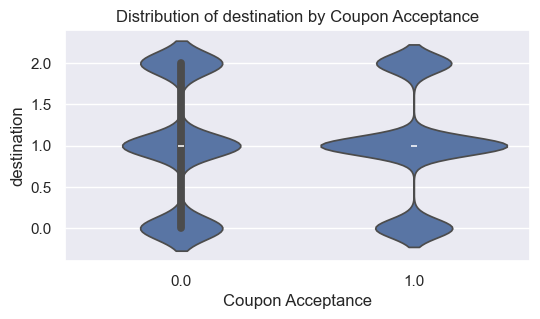

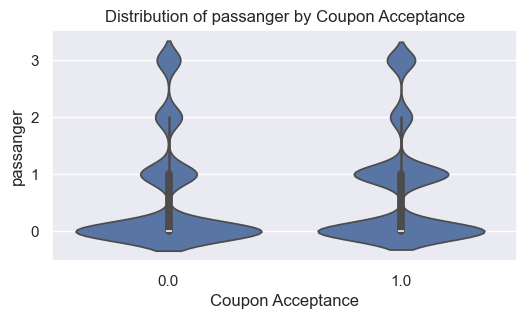

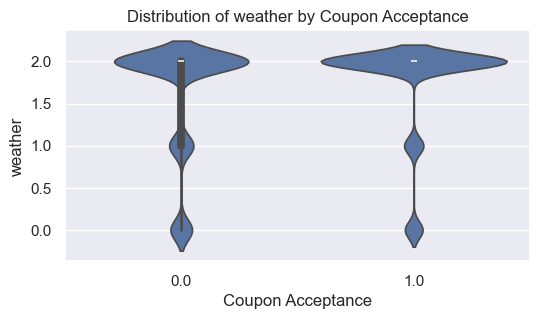

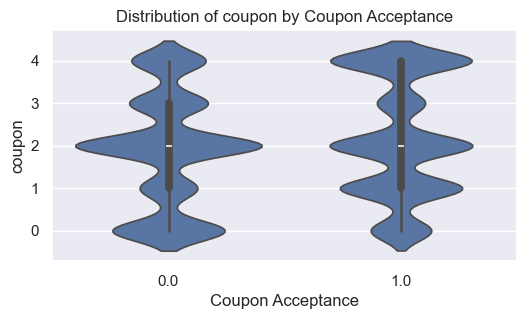

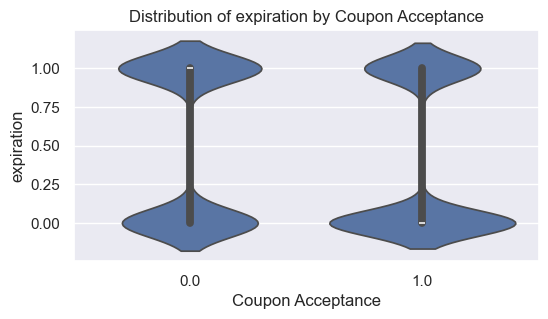

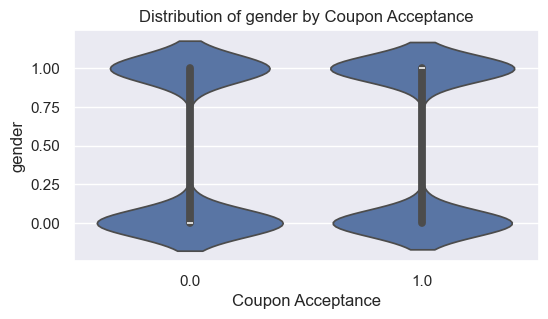

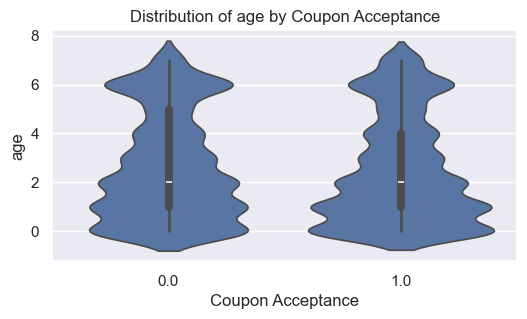

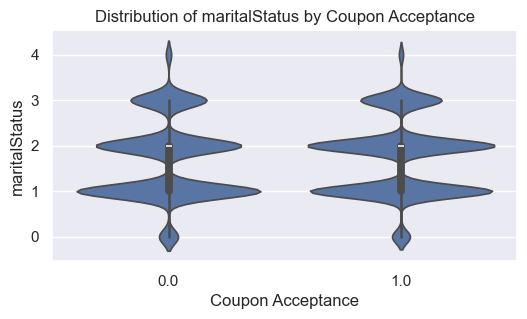

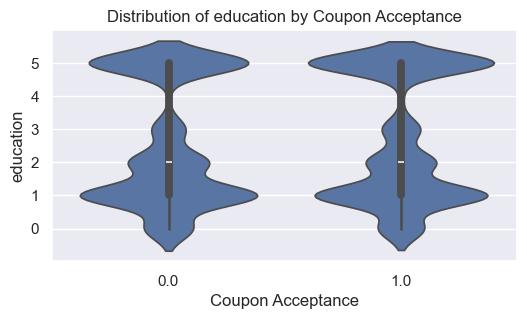

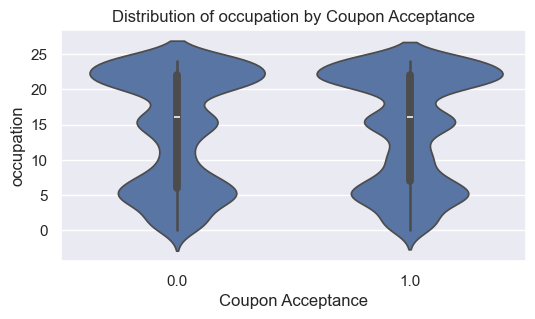

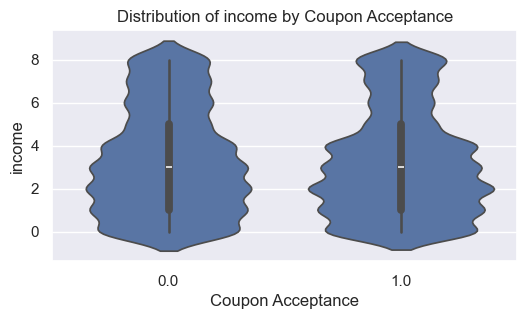

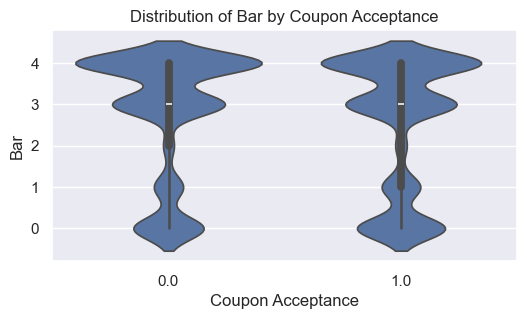

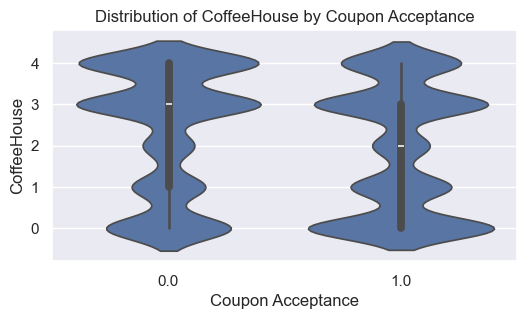

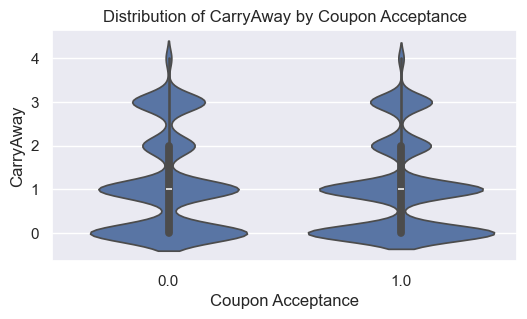

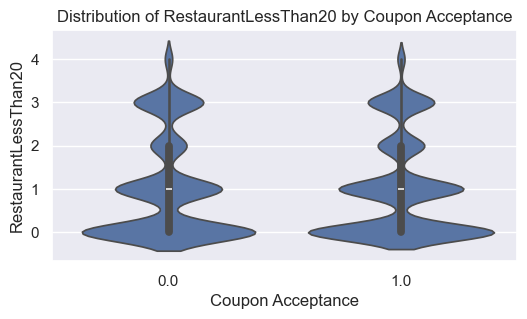

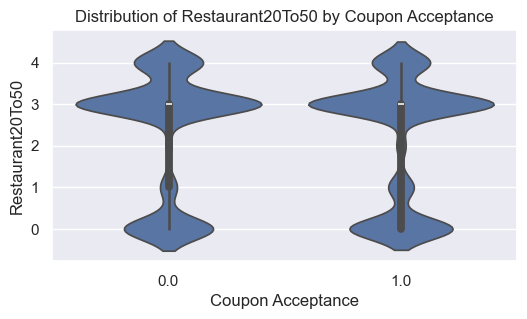

In [36]:
# Numerical Features against the Target Variable

for i in numerical_features:
    if i != "Accept(Y/N?)":
        plt.figure(figsize = (6, 3))
        sns.violinplot(data = df, x = "Accept(Y/N?)", y = i)
        plt.title(f"Distribution of {i} by Coupon Acceptance")
        plt.xlabel("Coupon Acceptance")
        plt.ylabel(i)
        plt.show()

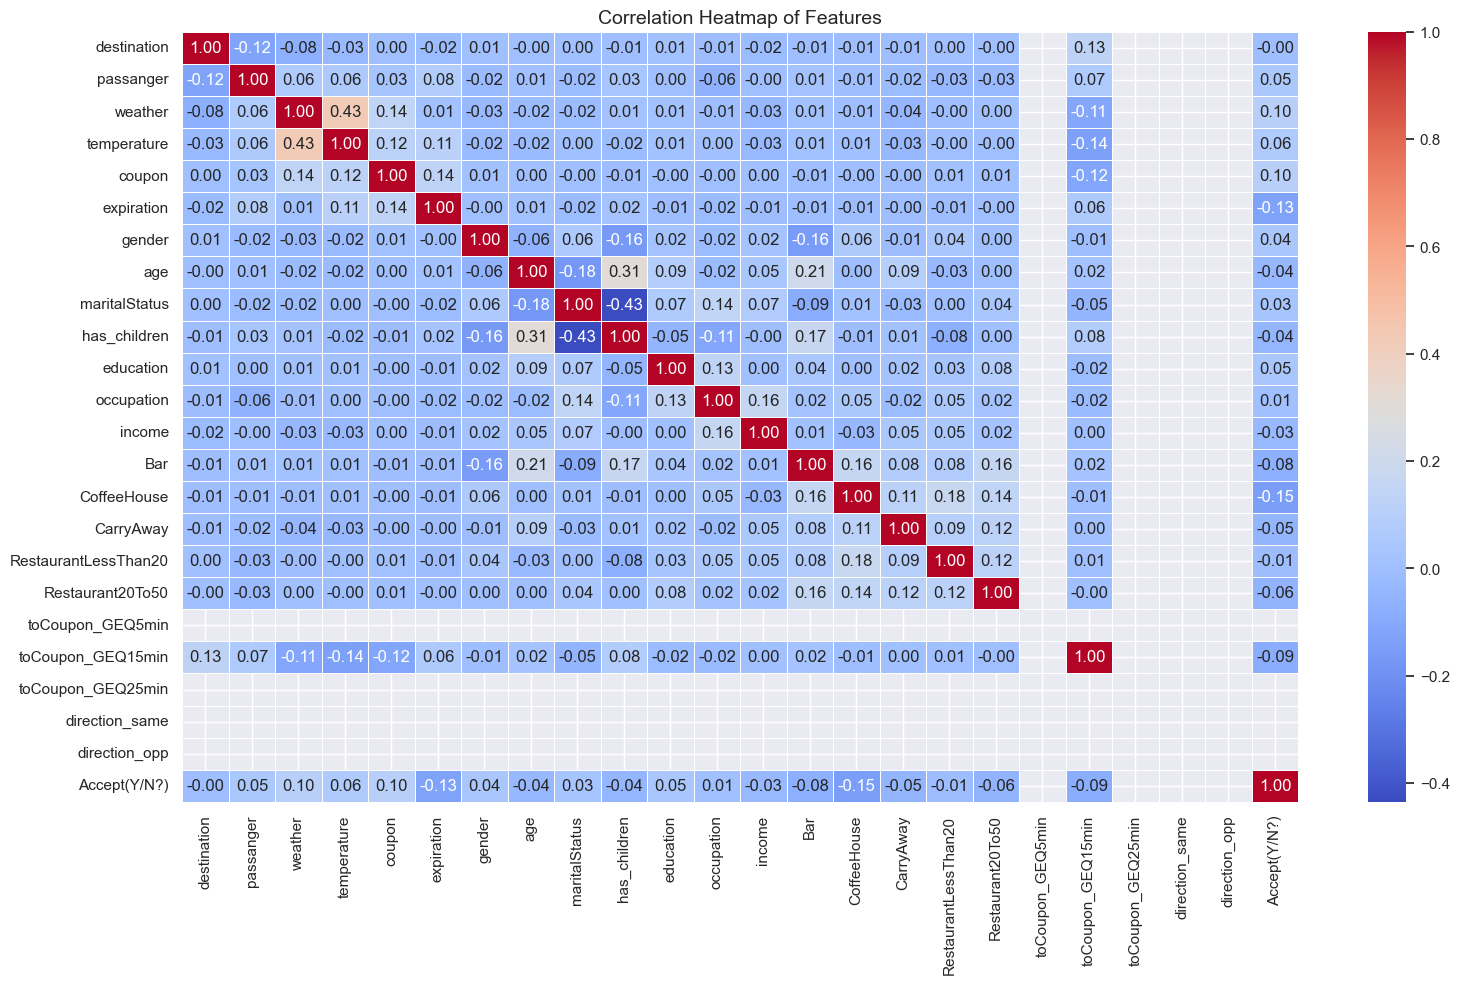

In [37]:
# Compute correlation matrix
corr_matrix = df.corr()

# Set up the matplotlib figure
plt.figure(figsize=(18,10))

# Generate a heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

# Title
plt.title("Correlation Heatmap of Features", fontsize=14)

# Show the plot
plt.show()

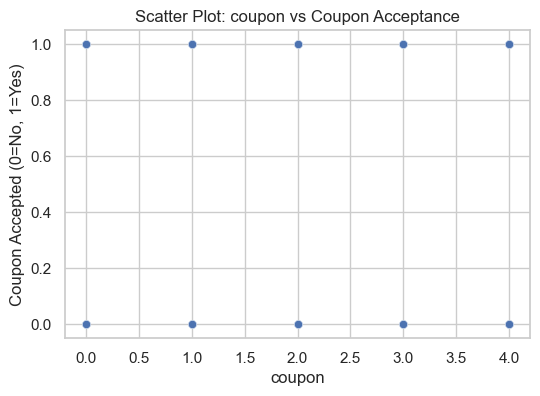

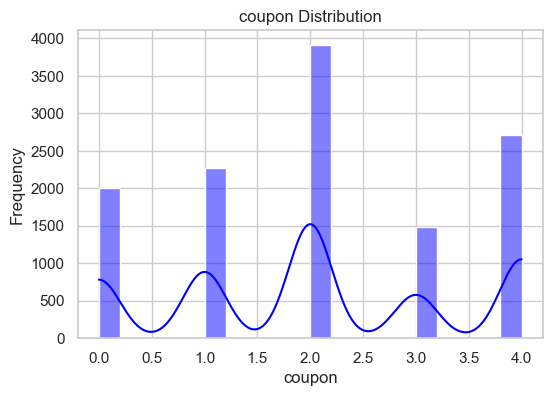

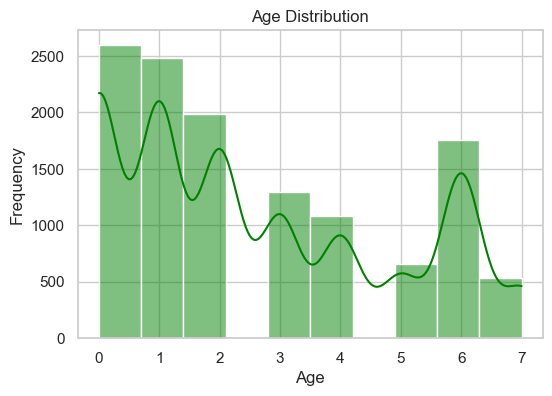

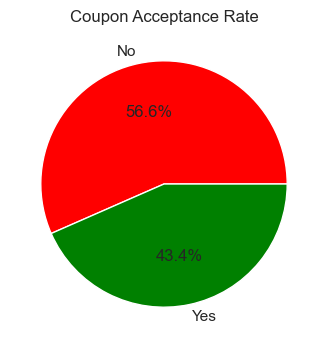

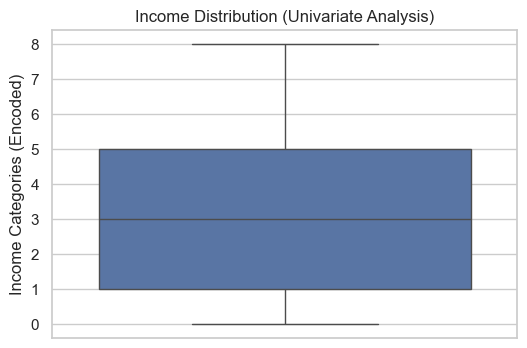

In [38]:
# Set style for better visualization
sns.set(style="whitegrid")

# Scatter Plot: Temperature vs. Coupon Acceptance
plt.figure(figsize=(6, 4))
sns.scatterplot(x=df["coupon"], y=df["Accept(Y/N?)"], alpha=0.5)
plt.title("Scatter Plot: coupon vs Coupon Acceptance")
plt.xlabel("coupon")
plt.ylabel("Coupon Accepted (0=No, 1=Yes)")
plt.show()

# Distribution Plot: Temperature
plt.figure(figsize=(6, 4))
sns.histplot(df["coupon"], bins=20, kde=True, color='blue')
plt.title("coupon Distribution")
plt.xlabel("coupon")
plt.ylabel("Frequency")
plt.show()

# Histogram: Age distribution
plt.figure(figsize=(6, 4))
sns.histplot(df["age"], bins=10, kde=True, color='green')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

# Pie Chart: Coupon Acceptance Rate
plt.figure(figsize=(6, 4))
df["Accept(Y/N?)"].value_counts().plot.pie(autopct="%1.1f%%", colors=["red", "green"], labels=["No", "Yes"])
plt.title("Coupon Acceptance Rate")
plt.ylabel("")
plt.show()

# Univariate Analysis: Box plot for income distribution
plt.figure(figsize=(6, 4))
sns.boxplot(y=df["income"])
plt.title("Income Distribution (Univariate Analysis)")
plt.ylabel("Income Categories (Encoded)")
plt.show()

In [39]:
!pip install dtale

In [3]:
# Import the D-Tale library for interactive data exploration
import dtale
# Launch an interactive web-based interface to explore the DataFrame
dtale.show(df)

In [41]:
#Check for Data Imbalance:

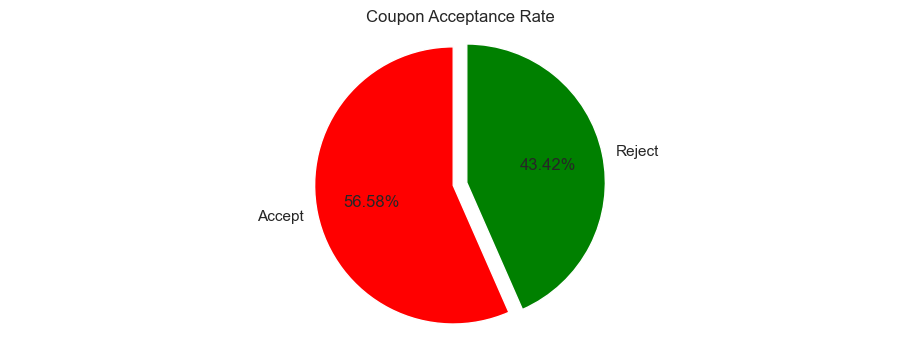

In [69]:
yesno_count = df["Accept(Y/N?)"].value_counts()

labels = ["Accept", "Reject"]
sizes = [yesno_count[1], yesno_count[0]]

plt.figure(figsize = (6, 4))
plt.pie(sizes, labels = labels, autopct = "%.2f%%", startangle = 90, colors=["red", "green"], explode = (0.1, 0))

# Equal aspect ratio ensures that pie is drawn as a circle.
plt.axis("equal")

plt.subplots_adjust(left = -0.5, right = 1.0)
plt.title("Coupon Acceptance Rate")
plt.show()

In [46]:
df["Accept(Y/N?)"].value_counts()

Accept(Y/N?)
1.0    7012
0.0    5381
Name: count, dtype: int64

In [48]:
df["Accept(Y/N?)"].value_counts(normalize = True)

Accept(Y/N?)
1.0    0.565803
0.0    0.434197
Name: proportion, dtype: float64

In [49]:
 #This case does not indicate a severe imbalance.
# There is no immediate need to use SMOTE or balance data.
# The data has relatively balanced proportions of acceptance and non-acceptance.

In [13]:
# Define features (X) and target (y)
X = df.drop(columns=["Accept(Y/N?)"])  # Features (X)
y = df["Accept(Y/N?)"]  # Target (y)

# Split into train & test sets
X_train, X_test, y_train, y_test = train_test_split(x_scaler, y, test_size=0.2, random_state=42, stratify=y)   
# train_test_split: This splits your dataset into training and test sets.
# test_size=0.2 means 20% of the data will be used as the test set, and the remaining 80% will be used for training.

print("Train shape:", X_train.shape)  # This prints the shape of the training feature set (X_train).
print("Test shape:", X_test.shape)    # This prints the shape of the testing feature set (X_test).

Train shape: (10147, 24)
Test shape: (2537, 24)


In [14]:
#Random Forest:
rfmodel = RandomForestClassifier() # Initialize the Random Forest classifier
rfmodel.fit(X_train, y_train) # Train (fit) the model using training data
y_pred_train = rfmodel.predict(X_train) # Make predictions on the training data
y_pred_test = rfmodel.predict(X_test) # Make predictions on the test data
print("Training Accuracy :", accuracy_score(y_train, y_pred_train)) # Calculate and print the accuracy on training data
print()
print("Test accuracy :", accuracy_score(y_test, y_pred_test)) # Calculate and print the accuracy on test data

Training Accuracy : 0.9923129989159357

Test accuracy : 0.73433188805676


In [15]:
# Import cross-validation function
from sklearn.model_selection import cross_val_score
training = cross_val_score(rfmodel, X_train, y_train, cv=10) # Perform 10-fold cross-validation on the training set
print(training) # Print the accuracy scores for each fold
print('************************')
print(training.mean()) # Print the mean accuracy across all folds

[0.73694581 0.74384236 0.73004926 0.73793103 0.71231527 0.75566502
 0.73891626 0.7642998  0.74260355 0.73964497]
************************
0.7402213348101941


In [16]:
#XG Boost:
# Initialize the XGBoost classifier
xgbmodel = XGBClassifier()
xgbmodel.fit(X_train, y_train) # Train (fit) the model using the training data
y_pred_train = xgbmodel.predict(X_train) # Make predictions on the training data
y_pred_test = xgbmodel.predict(X_test) # Make predictions on the test data
print("Training Accuracy :", accuracy_score(y_train, y_pred_train)) # Calculate and print the accuracy on training data
print()
print("Test accuracy :", accuracy_score(y_test, y_pred_test)) # Calculate and print the accuracy on test data

Training Accuracy : 0.9143589238198482

Test accuracy : 0.7571935356720536


In [54]:
from sklearn.model_selection import cross_val_score
training = cross_val_score(xgbmodel, X_train, y_train, cv=10) # Perform 10-fold cross-validation on the training set
print(training)  # Print the accuracy scores for each fold
print('************************')
print(training.mean())  # Print the mean accuracy across all folds

[0.73847926 0.74539171 0.71428571 0.73502304 0.74884793 0.74971165
 0.75201845 0.7289504  0.76585928 0.75547866]
************************
0.7434046104210186


In [55]:
#List of other models to evaluate:

In [59]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Ridge Classifier": RidgeClassifier(),
    "Perceptron": Perceptron(),
    "SVC": SVC(),
    "LinearSVC": LinearSVC(),
    "K-Neighbors": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Bernoulli Naive Bayes": BernoulliNB(),
    "Decision Tree": DecisionTreeClassifier(),
    
    
    
}

# Loop through models, train, predict, and evaluate
results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    # Extract precision, recall, and F1 score for each class dynamically
    class_metrics = {}
    for label in report.keys():
        if label != 'accuracy':  # Exclude 'accuracy' key
            class_metrics[f"Precision (Class {label})"] = report[label].get('precision', 0)
            class_metrics[f"Recall (Class {label})"] = report[label].get('recall', 0)
            class_metrics[f"F1-score (Class {label})"] = report[label].get('f1-score', 0)

    # Save results, ensuring to handle missing class data
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        **class_metrics
    })

# Create DataFrame from results
results_df = pd.DataFrame(results)

# Display the results, sorted by accuracy
print(results_df.sort_values(by="Accuracy", ascending=False))

                    Model  Accuracy  Precision (Class 0.0)  \
1       Gradient Boosting  0.718397               0.702935   
2                AdaBoost  0.681011               0.650281   
5                     SVC  0.678860               0.658850   
10          Decision Tree  0.675901               0.627892   
7             K-Neighbors  0.634481               0.587031   
9   Bernoulli Naive Bayes  0.633405               0.600480   
8    Gaussian Naive Bayes  0.631522               0.596367   
6               LinearSVC  0.622647               0.587552   
3        Ridge Classifier  0.622647               0.587552   
0     Logistic Regression  0.622378               0.587354   
4              Perceptron  0.585261               0.522360   

    Recall (Class 0.0)  F1-score (Class 0.0)  Precision (Class 1.0)  \
1             0.608426              0.652275               0.727704   
2             0.573730              0.609612               0.700087   
5             0.539653              0.5933

In [60]:
#Feature Impotance:

In [62]:
# Get feature importance values from the trained model
importances = model.feature_importances_

# Retrieve the feature names from the dataset
feature_names = X.columns

# Create a DataFrame to store feature names and their corresponding importance scores
feature_importance_df = pd.DataFrame({"Feature": feature_names, "Importance": importances})

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Display the top 10 most important features
print(feature_importance_df.head(25))

                 Feature  Importance
4                 coupon    0.111467
11            occupation    0.099469
12                income    0.078010
7                    age    0.071055
13                   Bar    0.058788
1              passanger    0.055586
14           CoffeeHouse    0.054612
10             education    0.050048
0            destination    0.049740
16  RestaurantLessThan20    0.047712
17      Restaurant20To50    0.046240
5             expiration    0.042530
15             CarryAway    0.041444
8          maritalStatus    0.039044
19     toCoupon_GEQ15min    0.038054
3            temperature    0.037959
2                weather    0.036966
6                 gender    0.024773
9           has_children    0.016504
18      toCoupon_GEQ5min    0.000000
20     toCoupon_GEQ25min    0.000000
21        direction_same    0.000000
22         direction_opp    0.000000


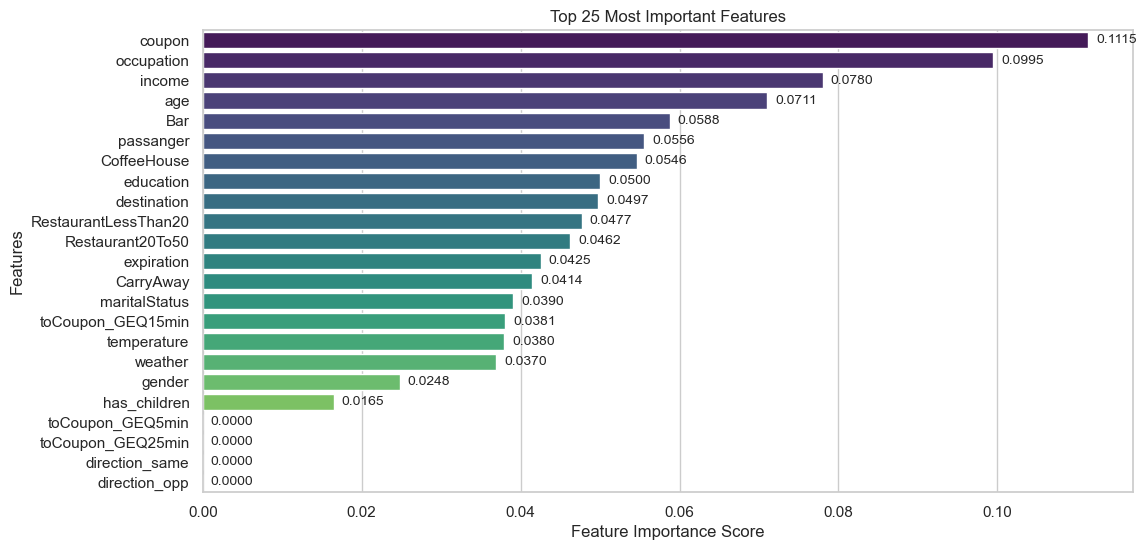

In [63]:
# Ensure feature importance data is in DataFrame format
feature_importance_df = pd.DataFrame({
    "Feature": feature_names, 
    "Importance": importances
})

# Sort features by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by="Importance", ascending=False)

# Ensure it's a DataFrame, not a Series
if isinstance(feature_importance_df, pd.Series):
    feature_importance_df = feature_importance_df.to_frame()

# Set figure size
plt.figure(figsize=(12, 6))

# Plot top 25 important features
sns.barplot(
    x="Importance", 
    y="Feature", 
    data=feature_importance_df.head(25),  # Ensure this is a DataFrame
    palette="viridis"
)

# Add labels and title
plt.xlabel("Feature Importance Score")
plt.ylabel("Features")
plt.title("Top 25 Most Important Features")

# Display importance values on bars
for index, value in enumerate(feature_importance_df["Importance"].head(25)):
    plt.text(value + 0.001, index, f"{value:.4f}", va="center", fontsize=10)

# Show the plot
plt.show()

In [64]:
#Make Prediction on test data and trained data:
y_pred = model.predict(X_test) # Predict the target variable for the test set using the trained model
y_pred_train = model.predict(X_train) # Predict the target variable for the training set using the trained model

# Get accuracy
accuracy_1 = accuracy_score(y_test, y_pred) # Calculate the accuracy of the model on the test set
accuracy_2 = accuracy_score(y_train, y_pred_train)  # Calculate the accuracy of the model on the training set

# Print the accuracy results
print(f"Test Set Model Accuracy: {accuracy_1:.4f}") # Print the accuracy on the test set
print(f"Training Set Model Accuracy: {accuracy_2:.4f}") # Print the accuracy on the training set

# Detailed classification report (Precision, Recall, F1-score)
print("\nClassification Report for Test Data:")
print(classification_report(y_test, y_pred))  # Generate and print the classification report for the test set
print("\nClassification Report for Training Data:")
print(classification_report(y_train, y_pred_train))  # Generate and print the classification report for the training set

Test Set Model Accuracy: 0.6759
Training Set Model Accuracy: 0.9881

Classification Report for Test Data:
              precision    recall  f1-score   support

         0.0       0.63      0.62      0.62      1614
         1.0       0.71      0.72      0.71      2104

    accuracy                           0.68      3718
   macro avg       0.67      0.67      0.67      3718
weighted avg       0.68      0.68      0.68      3718


Classification Report for Training Data:
              precision    recall  f1-score   support

         0.0       0.97      1.00      0.99      3767
         1.0       1.00      0.98      0.99      4908

    accuracy                           0.99      8675
   macro avg       0.99      0.99      0.99      8675
weighted avg       0.99      0.99      0.99      8675



In [65]:
from sklearn.model_selection import cross_val_score
training = cross_val_score(model, X_train, y_train, cv=10) # Perform 10-fold cross-validation on the training set
print(training) # Print the accuracy scores for each fold
print('************************')
print(training.mean())  # Print the mean accuracy across all folds

[0.6624424  0.67626728 0.66474654 0.68548387 0.66935484 0.6839677
 0.6805075  0.6805075  0.67128028 0.67589389]
************************
0.6750451793620674


In [66]:
#Cross Validation Score on Train Data:

In [67]:
# List of models to evaluate
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "AdaBoost": AdaBoostClassifier(),
    "Ridge Classifier": RidgeClassifier(),
    "Perceptron": Perceptron(),
    "SVC": SVC(),
    "LinearSVC": LinearSVC(),
    "K-Neighbors": KNeighborsClassifier(),
    "Gaussian Naive Bayes": GaussianNB(),
    "Bernoulli Naive Bayes": BernoulliNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "XGBoost": XGBClassifier(),
    
}

# Store results for cross-validation
cv_results = []

# Loop through models, calculate cross-validation score and store the results
for name, model in models.items():
    cv_score = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')  # 5-fold cross-validation
    mean_cv_score = np.mean(cv_score)  # Mean of the cross-validation scores
    cv_results.append({
        "Model": name,
        "Cross-Val Accuracy (Mean)": mean_cv_score,
        "Cross-Val Std Dev": np.std(cv_score)  # Standard deviation of the cross-validation scores
    })

# Convert the results to a DataFrame
cv_results_df = pd.DataFrame(cv_results)

# Display the results, sorted by mean cross-validation score
print(cv_results_df.sort_values(by="Cross-Val Accuracy (Mean)", ascending=False))

                    Model  Cross-Val Accuracy (Mean)  Cross-Val Std Dev
12                XGBoost                   0.743055           0.008850
1           Random Forest                   0.728876           0.010145
2       Gradient Boosting                   0.716311           0.007990
6                     SVC                   0.673199           0.006208
3                AdaBoost                   0.672507           0.008774
11          Decision Tree                   0.669164           0.003321
8             K-Neighbors                   0.639539           0.007599
10  Bernoulli Naive Bayes                   0.622939           0.004855
0     Logistic Regression                   0.619020           0.004958
4        Ridge Classifier                   0.619020           0.005540
7               LinearSVC                   0.619020           0.005540
9    Gaussian Naive Bayes                   0.610259           0.011279
5              Perceptron                   0.548703           0

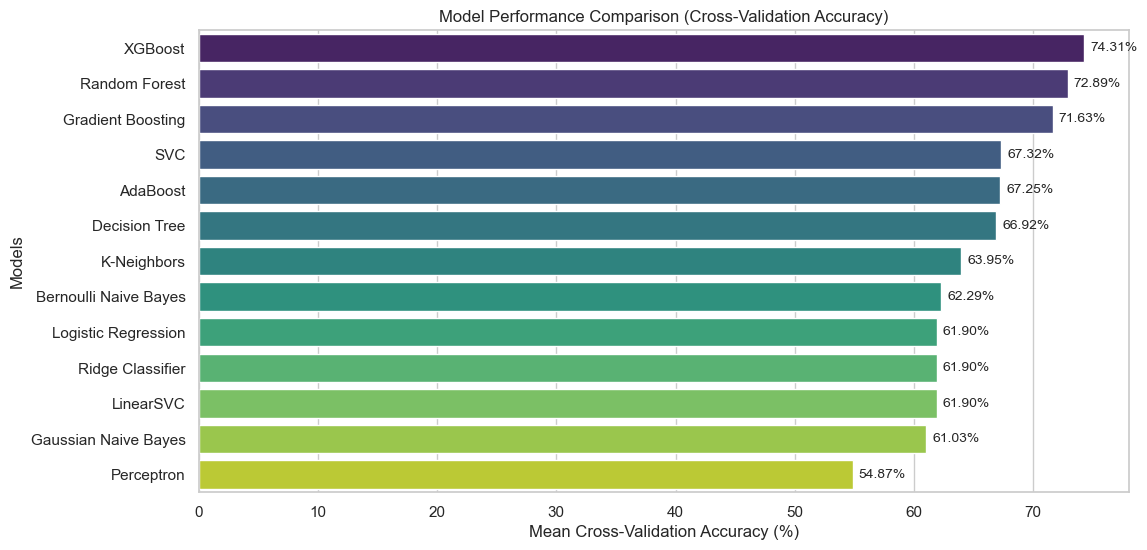

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert accuracy scores to percentages
cv_results_df_sorted = cv_results_df.sort_values(by="Cross-Val Accuracy (Mean)", ascending=False)
cv_results_df_sorted["Cross-Val Accuracy (Mean)"] *= 100  # Convert to percentage

# Set figure size
plt.figure(figsize=(12, 6))

# Create a horizontal bar plot
sns.barplot(
    x="Cross-Val Accuracy (Mean)", 
    y="Model", 
    data=cv_results_df_sorted, 
    palette="viridis"
)

# Add labels and title
plt.xlabel("Mean Cross-Validation Accuracy (%)")
plt.ylabel("Models")
plt.title("Model Performance Comparison (Cross-Validation Accuracy)")

# Display percentage labels on bars
for index, value in enumerate(cv_results_df_sorted["Cross-Val Accuracy (Mean)"]):
    plt.text(value + 0.5, index, f"{value:.2f}%", va="center", fontsize=10)

# Show the plot
plt.show()